# Simulated pure-space cross-smooth diagnostic: true smooth=0.5, fitted smooth=0.3

This notebook uses the Amarel-generated July ST circulant simulation assets copied to the local mac. It reads the `gridded.pkl` file so x8/x4/x2/x1 are all formed from a fixed regular grid before cluster Vecchia fitting.

The simulation truth is read from the transferred `truth.json`; the isotropic pure-space reference range is the geometric mean of the anisotropic latitude/longitude ranges.

This cross-fit version intentionally fits only `smooth=0.3` to data generated with `smooth=0.5`.


In [1]:
import gc
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import gamma as scipy_gamma
from scipy.special import kv as scipy_kv

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO.kernels_space_iso_cluster_052426 import (
    ClusterSpaceIsoTrendVecchiaFit,
    ClusterSpaceIsoNoNuggetTrendVecchiaFit,
)

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 5

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 200)
print('SRC:', SRC)
print('device:', DEVICE)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

FIT_SMOOTHS = [0.3]  # cross-fit: true smooth 0.5 data, fitted as smooth 0.3
SMOOTH = FIT_SMOOTHS[0]  # compatibility default; actual fits loop over FIT_SMOOTHS
RESOLUTION_STRIDES = [8, 4, 2, 1]
MEAN_DESIGN = 'latlon'

TRUE_SMOOTH = 0.5
# Overwritten from the transferred Amarel truth JSON below.
TRUE_PARAMS = {'sigmasq': np.nan, 'range': np.nan, 'nugget': np.nan}

CLUSTER_SPEC = {
    'block_shape': (4, 4),
    'n_neighbor_blocks': 2,
    'target_chunk_size': 128,
    'min_target_points': 1,
}

VARIANTS = {
    'nugget_free': {
        'class': ClusterSpaceIsoTrendVecchiaFit,
        'model': 'ClusterSpaceIso_4x4_B2_exactloc',
        'kernel': 'cluster_space_iso_4x4_b2_exactloc',
        'p_labels': ['sigmasq', 'range', 'nugget'],
        'init': {'sigmasq': 13.0, 'range': 0.25, 'nugget': 2.5},
    },
    'nugget0': {
        'class': ClusterSpaceIsoNoNuggetTrendVecchiaFit,
        'model': 'ClusterSpaceIsoNoNugget_4x4_B2_exactloc',
        'kernel': 'cluster_space_iso_nugget0_4x4_b2_exactloc',
        'p_labels': ['sigmasq', 'range'],
        'init': {'sigmasq': 13.0, 'range': 0.25},
    },
}

LBFGS_LR = 1.0
LBFGS_STEPS_FULL = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

RUN_FULL = True
RUN_SPECTRUM = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'sim_pure_space_true_s05_fit_s03_clusterb2_052426'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('true smooth:', TRUE_SMOOTH)
print('fit smooths:', FIT_SMOOTHS)
print('variants:', list(VARIANTS))


def smooth_tag(x):
    return str(float(x)).replace('.', 'p')


day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
true smooth: 0.5
fit smooths: [0.3]
variants: ['nugget_free', 'nugget0']


In [3]:
def phys_to_log(init, p_labels):
    return [np.log(init[p]) for p in p_labels]


def backmap(raw, p_labels, variant):
    est = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if 'nugget' not in est:
        est['nugget'] = 0.0
    return est


def make_full_params(variant):
    spec = VARIANTS[variant]
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(spec['init'], spec['p_labels'])]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    if hasattr(model, 'cluster_summary'):
        return dict(model.cluster_summary())

    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'


In [4]:
# Load Amarel-generated July ST circulant simulation copied to the local mac.
# The gridded pickle is used here because x8/x4/x2/x1 thinning must happen on
# a fixed regular grid. Each hour is sorted into the same latitude/longitude
# order before fitting, so the max-min cluster Vecchia ordering is comparable
# across resolutions.
SIM_LOCAL_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA/simulation')
SIM_DATA_ROOT_CANDIDATES = [SIM_LOCAL_ROOT / name for name in ['july_st_circulant_realpattern_smooth0p5']]
SIM_DATA_ROOT = None
for candidate_root in SIM_DATA_ROOT_CANDIDATES:
    candidate_pickle = candidate_root / f'{YEAR}_july_st_circulant' / f'sim_july{YEAR}_st_circulant_gridded.pkl'
    if candidate_pickle.exists():
        SIM_DATA_ROOT = candidate_root
        break
if SIM_DATA_ROOT is None:
    checked = '\n'.join(str(p) for p in SIM_DATA_ROOT_CANDIDATES)
    raise FileNotFoundError('Could not find transferred Amarel simulation data. Checked:\n' + checked)
SIM_YEAR_DIR = SIM_DATA_ROOT / f'{YEAR}_july_st_circulant'
SIM_PICKLE_PATH = SIM_YEAR_DIR / f'sim_july{YEAR}_st_circulant_gridded.pkl'
SIM_TRUTH_PATH = SIM_YEAR_DIR / f'sim_july{YEAR}_st_circulant_truth.json'

if not SIM_PICKLE_PATH.exists():
    raise FileNotFoundError(
        'Could not find transferred Amarel simulation gridded pickle. '
        f'Expected: {SIM_PICKLE_PATH}\n'
        'Run the Amarel -> mac transfer block in the matching slurm_generate_*.md file first.'
    )
if not SIM_TRUTH_PATH.exists():
    raise FileNotFoundError(f'Could not find simulation truth JSON: {SIM_TRUTH_PATH}')

sim_map_all = pd.read_pickle(SIM_PICKLE_PATH)
with SIM_TRUTH_PATH.open() as f:
    sim_truth = json.load(f)

TRUE_SMOOTH = float(sim_truth.get('smooth', TRUE_SMOOTH))
_range_lat = float(sim_truth.get('range_lat', np.nan))
_range_lon = float(sim_truth.get('range_lon', np.nan))
TRUE_PARAMS = {
    'sigmasq': float(sim_truth.get('sigmasq', np.nan)),
    # The pure-space fit is isotropic, so use the geometric mean of the
    # anisotropic simulation ranges as the scalar reference.
    'range': float(np.sqrt(_range_lat * _range_lon)) if np.isfinite(_range_lat * _range_lon) else np.nan,
    'nugget': float(sim_truth.get('nugget', np.nan)),
}

month_keys = sorted(sim_map_all.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

REQUIRED_COLS = ['Latitude', 'Longitude', 'ColumnAmountO3']


def sorted_regular_df(df):
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise KeyError(f'Simulation dataframe is missing columns: {missing}')
    tmp = df.reset_index(drop=True).copy()
    tmp['_orig_idx'] = np.arange(len(tmp))
    tmp = tmp.sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')
    return tmp.drop(columns=['_orig_idx']).reset_index(drop=True)


def tensor_from_regular_df(df):
    lat = pd.to_numeric(df['Latitude'], errors='coerce').to_numpy(np.float64)
    lon = pd.to_numeric(df['Longitude'], errors='coerce').to_numpy(np.float64)
    y = pd.to_numeric(df['ColumnAmountO3'], errors='coerce').to_numpy(np.float64)
    # Pure-space Vecchia kernels expect at least four columns because their
    # dummy conditioning rows mark column index 3. The fourth column is a
    # stable fixed-grid local id; likelihood uses columns 0, 1, and 2.
    local_id = np.arange(len(df), dtype=np.float64)
    arr = np.column_stack([lat, lon, y, local_id])
    return torch.as_tensor(arr, dtype=DTYPE, device=DEVICE)

first_df = sorted_regular_df(sim_map_all[day_keys[0]])
grid_coords_full = first_df[['Latitude', 'Longitude']].to_numpy(np.float64)
sim_hour_maps = {}
for key in day_keys:
    hour_df = sorted_regular_df(sim_map_all[key])
    coords = hour_df[['Latitude', 'Longitude']].to_numpy(np.float64)
    if coords.shape != grid_coords_full.shape or not np.allclose(coords, grid_coords_full, equal_nan=True):
        raise ValueError(f'Grid coordinates are not aligned for hour key {key}')
    sim_hour_maps[key] = tensor_from_regular_df(hour_df).contiguous()

month_vals = [pd.to_numeric(sim_map_all[k]['ColumnAmountO3'], errors='coerce').to_numpy(np.float64) for k in month_keys]
monthly_mean = float(np.nanmean(np.concatenate(month_vals)))

# Map each regular-grid point to row/column ids for stride thinning.
lat_vals = np.sort(np.unique(np.round(grid_coords_full[:, 0], 10)))
lon_vals = np.sort(np.unique(np.round(grid_coords_full[:, 1], 10)))
lat_to_row = {v: i for i, v in enumerate(lat_vals)}
lon_to_col = {v: i for i, v in enumerate(lon_vals)}
sim_local_to_row = np.array([lat_to_row[round(float(lat), 10)] for lat in grid_coords_full[:, 0]], dtype=np.int64)
sim_local_to_col = np.array([lon_to_col[round(float(lon), 10)] for lon in grid_coords_full[:, 1]], dtype=np.int64)
SIM_N_LAT = len(lat_vals)
SIM_N_LON = len(lon_vals)
SIM_LAT_STEP = float(np.median(np.diff(lat_vals))) if SIM_N_LAT > 1 else np.nan
SIM_LON_STEP = float(np.median(np.diff(lon_vals))) if SIM_N_LON > 1 else np.nan
sim_lat_vals = lat_vals
sim_lon_vals = lon_vals

print('Loaded transferred simulation:', SIM_PICKLE_PATH)
print('Truth:', sim_truth)
print('Day keys:', day_keys)
print('Grid:', SIM_N_LAT, 'x', SIM_N_LON, 'step:', SIM_LAT_STEP, SIM_LON_STEP)
print('Monthly mean:', monthly_mean)


Loaded transferred simulation: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2024_july_st_circulant/sim_july2024_st_circulant_gridded.pkl
Truth: {'year': 2024, 'input_template': '/home/jl2815/tco/data/pickle_2024/tco_grid_24_07.pkl', 'n_hours': 248, 'hours_per_day': 8, 'block_generation': 'independent daily 8-hour 3D circulant embeddings', 'smooth': 0.5, 'sigmasq': 10.0, 'sigma': 3.1622776601683795, 'range_lat': 0.2, 'range_lon': 0.3, 'range_time': 2.0, 'advec_lat': 0.08, 'advec_lon': -0.2, 'nugget': 1.0, 'mean_intercept': 260.0, 'mean_lat_slope': 1.0, 'mean_lat_center': -0.5, 'lat_range': [-3.0, 2.0], 'lon_range': [121.0, 131.0], 'delta_lat_base': 0.044, 'delta_lon_base': 0.063, 'lat_factor_hr': 100, 'lon_factor_hr': 10, 'delta_lat_hr': 0.00043999999999999996, 'delta_lon_hr': 0.0063, 'hr_pad': 0.1, 'griddification_rule': 'nearest regular grid cell, 1-to-1, then axis-wise half-cell threshold', 'griddification_threshold_lat': 0.022, 'griddifica

In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    return {key: sim_hour_maps[key].clone().to(DEVICE)}, key


def thin_hour_map(hour_map, stride):
    # True 2D resolution thinning on the regular lat/lon grid:
    # x8 keeps every 8th latitude and every 8th longitude, not every 8th
    # element in the flattened vector. This makes the spectrum Nyquist cut
    # k_max / stride meaningful.
    stride = int(stride)
    keep = (sim_local_to_row % stride == 0) & (sim_local_to_col % stride == 0)
    thin_idx = np.flatnonzero(keep).astype(np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def build_model(variant, input_map, grid_coords, fit_smooth=SMOOTH):
    spec = VARIANTS[variant]
    return spec['class'](
        smooth=float(fit_smooth),
        input_map=input_map,
        grid_coords=np.ascontiguousarray(grid_coords.astype(np.float64)),
        block_shape=CLUSTER_SPEC['block_shape'],
        n_neighbor_blocks=CLUSTER_SPEC['n_neighbor_blocks'],
        target_chunk_size=CLUSTER_SPEC['target_chunk_size'],
        min_target_points=CLUSTER_SPEC['min_target_points'],
        mean_design=MEAN_DESIGN,
    )


def make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag, fit_smooth):
    spec = VARIANTS[variant]
    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'variant': variant,
        'true_smooth': float(TRUE_SMOOTH),
        'fit_smooth': float(fit_smooth),
        'smooth': float(fit_smooth),
        'mean_design': MEAN_DESIGN,
        'fit_type': 'full',
        'model': spec['model'],
        'kernel': spec['kernel'],
        'coord_mode': 'regular-grid 2D every-k thinning, fixed thinned grid order; 4x4 cluster max-min ordering on cluster centroids; covariance on Source_Latitude/Source_Longitude',
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': float(est['sigmasq']),
        'est_range': float(est['range']),
        'est_nugget': float(est.get('nugget', 0.0)),
        **diag,
        'cluster_block_shape': '4x4',
        'cluster_neighbor_blocks': CLUSTER_SPEC['n_neighbor_blocks'],
        'total_conditioning_nominal': int(CLUSTER_SPEC['n_neighbor_blocks'] * np.prod(CLUSTER_SPEC['block_shape'])),
    }
    return row


In [6]:
def fit_full_variant(variant, hour_idx, stride, fit_smooth):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, _ = thin_hour_map(hour_map, stride)
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 100)
    print(f'{variant} | true_smooth={TRUE_SMOOTH} | fit_smooth={fit_smooth} | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(variant, thin_map, thin_grid, fit_smooth=fit_smooth)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_full_params(variant)
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_FULL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    p_labels = VARIANTS[variant]['p_labels']
    est = backmap(out[:len(p_labels)], p_labels, variant)
    row = make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag, fit_smooth)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['variant','fit_smooth','resolution_label','loss','est_sigmasq','est_range','est_nugget','total_s']})

    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row


In [7]:
fit_rows = []
if RUN_FULL:
    for fit_smooth in FIT_SMOOTHS:
        for variant in VARIANTS:
            for hour_idx in HOUR_IDX_LIST:
                for stride in RESOLUTION_STRIDES:
                    fit_rows.append(fit_full_variant(variant, hour_idx, stride, fit_smooth))
                tmp = round_df(pd.DataFrame(fit_rows))
                tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

fit_df = pd.DataFrame(fit_rows)
full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
round_df(fit_df).to_csv(full_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved full fits:', full_path)
display(round_df(fit_df))

param_rows = []
for _, row in fit_df.iterrows():
    for p in ['sigmasq', 'range', 'nugget']:
        param_rows.append({
            'date_str': row['date_str'],
            'hour_idx': int(row['hour_idx']),
            'time_key': row['time_key'],
            'resolution_stride': int(row['resolution_stride']),
            'resolution_label': row['resolution_label'],
            'variant': row['variant'],
            'true_smooth': row.get('true_smooth', TRUE_SMOOTH),
            'fit_smooth': row.get('fit_smooth', row['smooth']),
            'smooth': row['smooth'],
            'parameter': p,
            'estimate': row[f'est_{p}'],
            'loss': row['loss'],
            'n_grid': row['n_grid'],
            'n_valid': row['n_valid'],
        })
param_df = pd.DataFrame(param_rows)
param_path = OUT_DIR / f'{OUT_PREFIX}_param_table.csv'
round_df(param_df).to_csv(param_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved param table:', param_path)



nugget_free | true_smooth=0.5 | fit_smooth=0.3 | hour=1 | y24m07day03_hm00:53 | x8 | n_grid=300 | n_valid=300
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=20, max_points/block=16, target_blocks=20, target_points=300, m mean/med/max=27.0/28/32, target med/max=16/16
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.661998 / Max Grad: 5.86e-05 ---
--- Step 2/8 / Loss: 1.611334 / Max Grad: 5.10e-07 ---
Converged: max_grad 5.10e-07 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 2.9016186168093845, 'range': 0.36521340405138675, 'nugget': 6.489010623255152}
RESULT: {'resolution_label': 'x8', 'variant': 'nugget_free', 'fit_smooth': 0.3, 'loss': 1.6113, 'total_s': 0.0925, 'est_sigmasq': 2.9016, 'est_range': 0.3652, 'est_nugget': 6.489}

nugget_free | true_smooth=0.5 | fit_smooth=0.3 | hour=1 | y24m07day03_hm00:53 | x4 | n_grid=1,160 | n_valid=1,160
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=80, max_points/block=

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,variant,true_smooth,fit_smooth,smooth,mean_design,fit_type,model,kernel,coord_mode,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq,est_range,est_nugget,n_clusters,block_shape_lat,block_shape_lon,n_neighbor_blocks,max_points_per_cluster,n_target_blocks,n_target_points,n_batches,max_cond_points,median_cond_points,median_target_size,max_target_size,target_chunk_size,cluster_block_shape,cluster_neighbor_blocks,total_conditioning_nominal
0,20240703,2,0,y24m07day03_hm00:53,8,x8,nugget_free,0.5,0.3,0.3,latlon,full,ClusterSpaceIso_4x4_B2_exactloc,cluster_space_iso_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.6113,1,2,0.0015,0.0910,0.0925,300,300,1.0000,2.9016,0.3652,6.4890,20,4,4,2,16,20,300,2,32,32.0,14.0,16,128,4x4,2,32
1,20240703,2,0,y24m07day03_hm00:53,4,x4,nugget_free,0.5,0.3,0.3,latlon,full,ClusterSpaceIso_4x4_B2_exactloc,cluster_space_iso_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.6147,0,1,0.0027,0.0809,0.0836,1160,1160,1.0000,8.9392,0.2802,1.7149,80,4,4,2,16,80,1160,2,32,32.0,10.0,16,128,4x4,2,32
2,20240703,2,0,y24m07day03_hm00:53,2,x2,nugget_free,0.5,0.3,0.3,latlon,full,ClusterSpaceIso_4x4_B2_exactloc,cluster_space_iso_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.3862,1,2,0.0074,0.5897,0.5971,4560,4531,0.9936,10.6030,0.2677,0.0000,300,4,4,2,16,300,4531,6,32,32.0,12.5,16,128,4x4,2,32
3,20240703,2,0,y24m07day03_hm00:53,1,x1,nugget_free,0.5,0.3,0.3,latlon,full,ClusterSpaceIso_4x4_B2_exactloc,cluster_space_iso_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.1783,1,2,0.1014,2.7013,2.8027,18126,18067,0.9967,10.2643,0.2698,0.0001,1160,4,4,2,16,1160,18067,6,32,32.0,10.5,16,128,4x4,2,32
4,20240703,2,1,y24m07day03_hm01:53,8,x8,nugget_free,0.5,0.3,0.3,latlon,full,ClusterSpaceIso_4x4_B2_exactloc,cluster_space_iso_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.6952,1,2,0.0011,0.1004,0.1015,300,292,0.9733,9.4843,0.1945,1.6727,20,4,4,2,16,20,292,5,32,32.0,12.0,16,128,4x4,2,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,20240703,2,6,y24m07day03_hm06:48,1,x1,nugget0,0.5,0.3,0.3,latlon,full,ClusterSpaceIsoNoNugget_4x4_B2_exactloc,cluster_space_iso_nugget0_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.1987,0,1,0.1665,1.0415,1.2081,18126,17887,0.9868,11.6844,0.3370,0.0000,1160,4,4,2,16,1160,17887,9,32,32.0,12.0,16,128,4x4,2,32
60,20240703,2,7,y24m07day03_hm07:48,8,x8,nugget0,0.5,0.3,0.3,latlon,full,ClusterSpaceIsoNoNugget_4x4_B2_exactloc,cluster_space_iso_nugget0_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.7186,0,1,0.0010,0.0256,0.0266,300,297,0.9900,12.0863,0.2462,0.0000,20,4,4,2,16,20,297,4,32,32.0,13.5,16,128,4x4,2,32
61,20240703,2,7,y24m07day03_hm07:48,4,x4,nugget0,0.5,0.3,0.3,latlon,full,ClusterSpaceIsoNoNugget_4x4_B2_exactloc,cluster_space_iso_nugget0_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.6073,0,1,0.0033,0.0686,0.0719,1160,1151,0.9922,12.5028,0.3040,0.0000,80,4,4,2,16,80,1151,4,32,32.0,14.5,16,128,4x4,2,32
62,20240703,2,7,y24m07day03_hm07:48,2,x2,nugget0,0.5,0.3,0.3,latlon,full,ClusterSpaceIsoNoNugget_4x4_B2_exactloc,cluster_space_iso_nugget0_4x4_b2_exactloc,"regular-grid 2D every-k thinning, fixed thinne...",1.4117,0,1,0.0076,0.2861,0.2937,4560,4491,0.9849,12.8228,0.3673,0.0000,300,4,4,2,16,300,4491,6,32,32.0,13.0,16,128,4x4,2,32


Saved param table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_param_table.csv


In [8]:
# Full-fit results table.
plot_df = fit_df.copy()
plot_df['resolution_label'] = pd.Categorical(
    plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_df = plot_df.sort_values(['fit_smooth', 'variant', 'hour_idx', 'resolution_label'])

display(round_df(plot_df[['true_smooth','fit_smooth','variant','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_nugget','n_grid','n_valid','total_s']]))


,true_smooth,fit_smooth,variant,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_nugget,n_grid,n_valid,total_s
32,0.5,0.3,nugget0,0,8,x8,1.6348,9.4241,0.1643,0.0000,300,300,0.0396
33,0.5,0.3,nugget0,0,4,x4,1.5856,10.6180,0.2221,0.0000,1160,1160,0.0676
34,0.5,0.3,nugget0,0,2,x2,1.3862,10.6005,0.2676,0.0000,4560,4531,0.4589
35,0.5,0.3,nugget0,0,1,x1,1.1961,10.2653,0.2698,0.0000,18126,18067,1.0648
36,0.5,0.3,nugget0,1,8,x8,1.7020,11.1681,0.1787,0.0000,300,292,0.0326
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,0.5,0.3,nugget_free,6,1,x1,1.1810,11.6844,0.3370,0.0000,18126,17887,2.8970
28,0.5,0.3,nugget_free,7,8,x8,1.7174,12.0861,0.2462,0.0001,300,297,0.1572
29,0.5,0.3,nugget_free,7,4,x4,1.6031,12.5026,0.3040,0.0002,1160,1151,0.2810
30,0.5,0.3,nugget_free,7,2,x2,1.3996,12.8233,0.3673,0.0000,4560,4491,0.8609


Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=20, max_points/block=16, target_blocks=20, target_points=300, m mean/med/max=27.0/28/32, target med/max=16/16

------------------------------------------------------------------------------------------
profile=sigma_only | nugget_free | true_smooth=0.5 | fit_smooth=0.3 | hour=1 | x8 | anchor={'sigmasq': 2.9016186168093845, 'range': 0.36521340405138675, 'nugget': 6.489010623255152}
    sigma_only step 1/8: loss=1.611334, grad=5.10e-07

------------------------------------------------------------------------------------------
profile=range_only | nugget_free | true_smooth=0.5 | fit_smooth=0.3 | hour=1 | x8 | anchor={'sigmasq': 2.9016186168093845, 'range': 0.36521340405138675, 'nugget': 6.489010623255152}
    range_only step 1/8: loss=1.611334, grad=5.10e-07
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=80, max_points/block=16, target_blocks=80, target_points=1160, m mean/med/max=27

,true_smooth,fit_smooth,variant,profile_type,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_nugget,fixed_sigmasq,fixed_range,fixed_nugget,n_grid,n_valid,total_s
0,0.5,0.3,nugget_free,sigma_only,0,8,x8,1.6113,2.9016,0.3652,6.4890,NaN,0.3652,6.4890,300,300,0.0049
1,0.5,0.3,nugget_free,range_only,0,8,x8,1.6113,2.9016,0.3652,6.4890,2.9016,NaN,6.4890,300,300,0.0040
2,0.5,0.3,nugget_free,sigma_only,0,4,x4,1.5783,8.9392,0.2802,1.7149,NaN,0.2802,1.7149,1160,1160,0.0075
3,0.5,0.3,nugget_free,range_only,0,4,x4,1.5783,8.9392,0.2802,1.7149,8.9392,NaN,1.7149,1160,1160,0.0072
4,0.5,0.3,nugget_free,sigma_only,0,2,x2,1.3862,10.6030,0.2677,0.0000,NaN,0.2677,0.0000,4560,4531,0.0302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0.5,0.3,nugget0,range_only,7,4,x4,1.6031,12.5028,0.3040,0.0000,12.5028,NaN,0.0000,1160,1151,0.0101
124,0.5,0.3,nugget0,sigma_only,7,2,x2,1.3995,12.8228,0.3673,0.0000,NaN,0.3673,0.0000,4560,4491,0.0310
125,0.5,0.3,nugget0,range_only,7,2,x2,1.3995,12.8228,0.3673,0.0000,12.8228,NaN,0.0000,4560,4491,0.0346
126,0.5,0.3,nugget0,sigma_only,7,1,x1,1.1766,11.8665,0.3515,0.0000,NaN,0.3515,0.0000,18126,17892,0.3726


Saved parameter plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_param_trajectories_fit_s0p3.png


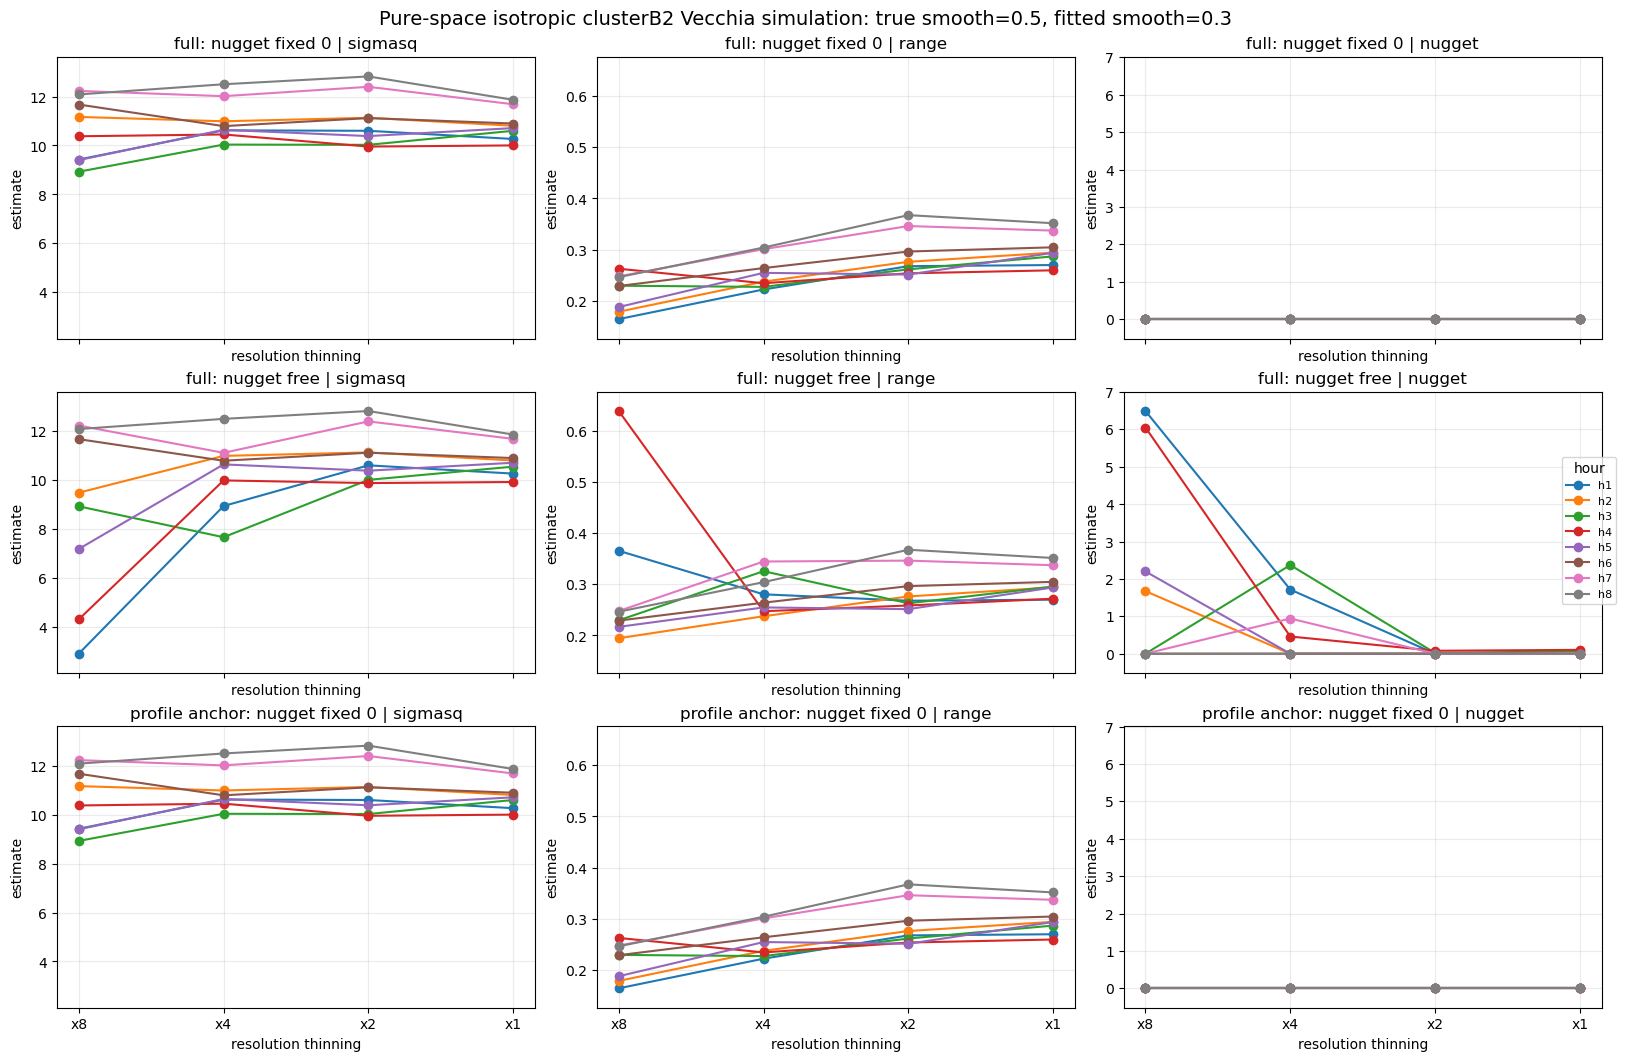

In [9]:
# %%
# Partial-profile fits anchored at the full-fit estimates.
# sigma_only: estimate sigmasq only; keep range and nugget fixed at the full-fit estimates.
# range_only: estimate range only; keep sigmasq and nugget fixed at the full-fit estimates.
RUN_PROFILE_FITS = True
PROFILE_TYPES = ['sigma_only', 'range_only']
PROFILE_LBFGS_STEPS = 8
PROFILE_GRAD_TOL = 1e-5
PROFILE_EPS = 1e-10


def safe_log_value(x, eps=PROFILE_EPS):
    return float(np.log(max(float(x), eps)))


def log_tensor_value(x, like, eps=PROFILE_EPS):
    return torch.as_tensor(np.log(max(float(x), eps)), device=like.device, dtype=like.dtype)


def profile_param_tensor(variant, profile_type, theta, anchor):
    if variant == 'nugget_free':
        vals = {
            'sigmasq': log_tensor_value(anchor['sigmasq'], theta),
            'range': log_tensor_value(anchor['range'], theta),
            'nugget': log_tensor_value(anchor['nugget'], theta),
        }
        vals['sigmasq' if profile_type == 'sigma_only' else 'range'] = theta.reshape(())
        return torch.stack([vals['sigmasq'], vals['range'], vals['nugget']])
    if variant == 'nugget0':
        vals = {
            'sigmasq': log_tensor_value(anchor['sigmasq'], theta),
            'range': log_tensor_value(anchor['range'], theta),
        }
        vals['sigmasq' if profile_type == 'sigma_only' else 'range'] = theta.reshape(())
        return torch.stack([vals['sigmasq'], vals['range']])
    raise ValueError(f'Unknown variant: {variant}')


def profile_estimate_from_theta(profile_type, theta, anchor):
    est = dict(anchor)
    est['sigmasq' if profile_type == 'sigma_only' else 'range'] = float(torch.exp(theta.detach()).cpu().item())
    return est


def optimize_profile(model, variant, profile_type, anchor):
    free_name = 'sigmasq' if profile_type == 'sigma_only' else 'range'
    theta = torch.tensor([safe_log_value(anchor[free_name])], device=DEVICE, dtype=DTYPE, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [theta],
        lr=LBFGS_LR,
        max_iter=LBFGS_EVAL,
        max_eval=LBFGS_EVAL,
        history_size=LBFGS_HIST,
        line_search_fn='strong_wolfe',
    )

    last_loss = None
    last_iter = 0
    for i in range(PROFILE_LBFGS_STEPS):
        last_iter = i

        def closure():
            optimizer.zero_grad()
            params = profile_param_tensor(variant, profile_type, theta, anchor)
            loss = model.vecchia_batched_likelihood(params)
            loss.backward()
            return loss

        last_loss = optimizer.step(closure)
        with torch.no_grad():
            max_grad = abs(float(theta.grad.detach().item())) if theta.grad is not None else 0.0
            print(f'    {profile_type} step {i + 1}/{PROFILE_LBFGS_STEPS}: loss={float(last_loss.detach().item()):.6f}, grad={max_grad:.2e}')
            if max_grad < PROFILE_GRAD_TOL:
                break

    est = profile_estimate_from_theta(profile_type, theta, anchor)
    loss = float(last_loss.detach().cpu().item()) if isinstance(last_loss, torch.Tensor) else np.nan
    return est, loss, last_iter


def fit_partial_profiles_for_row(row):
    variant = str(row['variant'])
    hour_idx = int(row['hour_idx'])
    stride = int(row['resolution_stride'])
    fit_smooth = float(row.get('fit_smooth', row.get('smooth', SMOOTH)))
    anchor = {
        'sigmasq': float(row['est_sigmasq']),
        'range': float(row['est_range']),
        'nugget': float(row.get('est_nugget', 0.0)),
    }

    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, _ = thin_hour_map(hour_map, stride)
    model = build_model(variant, thin_map, thin_grid, fit_smooth=fit_smooth)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    out_rows = []
    for profile_type in PROFILE_TYPES:
        print('\n' + '-' * 90)
        print(f"profile={profile_type} | {variant} | true_smooth={TRUE_SMOOTH} | fit_smooth={fit_smooth} | hour={hour_idx + 1} | {resolution_label(stride)} | anchor={anchor}")
        t_fit = time.time()
        est, loss, fit_iter = optimize_profile(model, variant, profile_type, anchor)
        fit_s = time.time() - t_fit
        profile_row = dict(row)
        profile_row.update({
            'fit_type': profile_type,
            'profile_type': profile_type,
            'true_smooth': float(TRUE_SMOOTH),
            'fit_smooth': float(fit_smooth),
            'smooth': float(fit_smooth),
            'fixed_sigmasq': anchor['sigmasq'] if profile_type == 'range_only' else np.nan,
            'fixed_range': anchor['range'] if profile_type == 'sigma_only' else np.nan,
            'fixed_nugget': anchor['nugget'],
            'loss': float(loss),
            'fit_iter_raw': int(fit_iter),
            'fit_steps_reported': int(fit_iter) + 1,
            'precompute_s': float(pre_s),
            'fit_s': float(fit_s),
            'total_s': float(pre_s + fit_s),
            'est_sigmasq': float(est['sigmasq']),
            'est_range': float(est['range']),
            'est_nugget': float(est.get('nugget', 0.0)),
            **diag,
        })
        out_rows.append(profile_row)

    del model, hour_map, thin_map
    empty_cache()
    return out_rows


profile_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv'
if RUN_PROFILE_FITS:
    if 'fit_df' not in globals() or fit_df.empty:
        fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')

    profile_rows = []
    for _, fit_row in fit_df.iterrows():
        profile_rows.extend(fit_partial_profiles_for_row(fit_row))
        tmp = round_df(pd.DataFrame(profile_rows))
        tmp.to_csv(profile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')

    profile_df = pd.DataFrame(profile_rows)
    round_df(profile_df).to_csv(profile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
else:
    profile_df = pd.read_csv(profile_path) if profile_path.exists() else pd.DataFrame()

print('Saved partial-profile fits:', profile_path)
display(round_df(profile_df[['true_smooth','fit_smooth','variant','profile_type','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_nugget','fixed_sigmasq','fixed_range','fixed_nugget','n_grid','n_valid','total_s']]))


# %%
# Combined parameter trajectories, one 3x3 matrix per fitted smooth.
if 'fit_df' not in globals() or fit_df.empty:
    fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')
if 'profile_df' not in globals() or profile_df.empty:
    profile_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv')

full_plot_df = fit_df.copy()
prof_plot_df = profile_df.copy()
for df in [full_plot_df, prof_plot_df]:
    df['resolution_label'] = pd.Categorical(
        df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
    )

prof_anchor_variant = 'nugget0'

combined_param_values = {
    'sigmasq': [full_plot_df['est_sigmasq'], prof_plot_df.loc[prof_plot_df['profile_type'] == 'sigma_only', 'est_sigmasq']],
    'range': [full_plot_df['est_range'], prof_plot_df.loc[prof_plot_df['profile_type'] == 'range_only', 'est_range']],
    'nugget': [full_plot_df['est_nugget'], prof_plot_df['fixed_nugget']],
}
combined_param_ylims = {}
for p, series_list in combined_param_values.items():
    vals = pd.concat([pd.to_numeric(s, errors='coerce') for s in series_list], ignore_index=True)
    vals = vals.replace([np.inf, -np.inf], np.nan).dropna()
    if vals.empty:
        combined_param_ylims[p] = (0.0, 1.0)
        continue
    lo, hi = float(vals.min()), float(vals.max())
    pad = max(abs(hi) * 0.05, 0.05) if np.isclose(lo, hi) else 0.08 * (hi - lo)
    if p == 'nugget':
        lo = min(0.0, lo)
    combined_param_ylims[p] = (lo - pad, hi + pad)

params = [
    ('sigmasq', 'sigmasq'),
    ('range', 'range'),
    ('nugget', 'nugget'),
]
row_specs = [
    ('full_nugget0', 'full: nugget fixed 0'),
    ('full_nugget_free', 'full: nugget free'),
    ('profile_nugget0', 'profile anchor: nugget fixed 0'),
]

for fit_smooth in sorted(pd.to_numeric(full_plot_df['fit_smooth'], errors='coerce').dropna().unique()):
    full_s = full_plot_df[np.isclose(full_plot_df['fit_smooth'].astype(float), fit_smooth)].copy()
    prof_s = prof_plot_df[np.isclose(prof_plot_df['fit_smooth'].astype(float), fit_smooth)].copy()
    fig, axes = plt.subplots(3, 3, figsize=(16, 10.5), constrained_layout=True, sharex=True)
    for i, (row_key, row_title) in enumerate(row_specs):
        for j, (p, p_title) in enumerate(params):
            ax = axes[i, j]
            if row_key == 'full_nugget0':
                sub = full_s[full_s['variant'] == 'nugget0'].sort_values(['hour_idx', 'resolution_label'])
                y_col = f'est_{p}'
            elif row_key == 'full_nugget_free':
                sub = full_s[full_s['variant'] == 'nugget_free'].sort_values(['hour_idx', 'resolution_label'])
                y_col = f'est_{p}'
            else:
                if p == 'sigmasq':
                    sub = prof_s[(prof_s['variant'] == prof_anchor_variant) & (prof_s['profile_type'] == 'sigma_only')].sort_values(['hour_idx', 'resolution_label'])
                    y_col = 'est_sigmasq'
                elif p == 'range':
                    sub = prof_s[(prof_s['variant'] == prof_anchor_variant) & (prof_s['profile_type'] == 'range_only')].sort_values(['hour_idx', 'resolution_label'])
                    y_col = 'est_range'
                else:
                    sub = prof_s[(prof_s['variant'] == prof_anchor_variant) & (prof_s['profile_type'] == 'sigma_only')].sort_values(['hour_idx', 'resolution_label'])
                    y_col = 'fixed_nugget'
            if sub.empty or y_col not in sub:
                ax.set_visible(False)
                continue
            for hour_idx, hs in sub.groupby('hour_idx'):
                ax.plot(hs['resolution_label'].astype(str), hs[y_col], marker='o', linewidth=1.5, label=f'h{int(hour_idx) + 1}')
            ax.set_title(f'{row_title} | {p_title}')
            ax.set_xlabel('resolution thinning')
            ax.set_ylabel('estimate')
            ax.set_ylim(*combined_param_ylims[p])
            ax.grid(True, alpha=0.25)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.01, 0.5), fontsize=8, title='hour')
    fig.suptitle(
        f'Pure-space isotropic clusterB2 Vecchia simulation: true smooth={TRUE_SMOOTH}, fitted smooth={fit_smooth}',
        fontsize=14,
    )
    param_plot_path = OUT_DIR / f'{OUT_PREFIX}_param_trajectories_fit_s{smooth_tag(fit_smooth)}.png'
    fig.savefig(param_plot_path, dpi=180, bbox_inches='tight')
    print('Saved parameter plot:', param_plot_path)
    plt.show()


## Spectral diagnostic

The empirical spectrum uses the same thinned points as each fit. Residuals are computed after an OLS trend matched to `MEAN_DESIGN`, placed back onto the actual thinned 2D grid, tapered, zero-filled, FFTed, and radially averaged.

The main model diagnostic compares the empirical periodogram `I` against a finite-sample DW-style expected periodogram `E[I(W)]`: the fitted Matérn covariance plus nugget is passed through the same mean projection, thinning grid, mask, Hann taper, zero-fill FFT normalization, and radial binning. No median rescaling is used in the main red curve. A median-matched continuous Matérn curve is kept only as a separate shape diagnostic.

In [10]:
SPECTRAL_SMOOTH = SMOOTH
RADIAL_N_BINS = 70
RADIAL_QMAX = 0.985
APPLY_HANN = True
EPS = 1e-12

_lat_key = np.round(grid_coords_full[:, 0], 10)
_lon_key = np.round(grid_coords_full[:, 1], 10)
lat_vals = np.sort(np.unique(_lat_key))
lon_vals = np.sort(np.unique(_lon_key))
lat_to_row = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_col = {float(v): i for i, v in enumerate(lon_vals)}
local_to_row = np.asarray([lat_to_row[float(v)] for v in _lat_key], dtype=np.int64)
local_to_col = np.asarray([lon_to_col[float(v)] for v in _lon_key], dtype=np.int64)
N_LAT, N_LON = len(lat_vals), len(lon_vals)
LAT_STEP = float(np.median(np.diff(lat_vals))) if N_LAT > 1 else 1.0
LON_STEP = float(np.median(np.diff(lon_vals))) if N_LON > 1 else 1.0
print('spectral full grid:', (N_LAT, N_LON), 'lat/lon step:', LAT_STEP, LON_STEP)


def trend_design(lat, lon, lat_center=None, lon_center=None):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    lat_center = np.nanmean(lat) if lat_center is None else float(lat_center)
    lon_center = np.nanmean(lon) if lon_center is None else float(lon_center)
    lat_c = lat - lat_center
    lon_c = lon - lon_center
    if MEAN_DESIGN == 'base':
        return np.column_stack([np.ones(len(lat))])
    if MEAN_DESIGN == 'lat':
        return np.column_stack([np.ones(len(lat)), lat_c])
    return np.column_stack([np.ones(len(lat)), lat_c, lon_c])


def axis_step(axis_vals):
    axis_vals = np.asarray(axis_vals, dtype=float)
    return float(np.median(np.diff(axis_vals))) if len(axis_vals) > 1 else 1.0


def detrended_residual_grid(hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, thin_idx = thin_hour_map(hour_map, stride)
    arr = next(iter(thin_map.values())).detach().cpu().numpy()
    y = arr[:, 2].astype(float)
    lat = arr[:, 0].astype(float)
    lon = arr[:, 1].astype(float)
    valid = np.isfinite(y) & np.isfinite(lat) & np.isfinite(lon)
    if valid.sum() < 4:
        raise ValueError(f'Not enough valid points for hour={hour_idx}, stride={stride}')

    lat_center = np.nanmean(lat[valid])
    lon_center = np.nanmean(lon[valid])
    X = trend_design(lat[valid], lon[valid], lat_center=lat_center, lon_center=lon_center)
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    X_all = trend_design(lat, lon, lat_center=lat_center, lon_center=lon_center)
    resid = y - X_all @ beta

    rows_full = local_to_row[thin_idx]
    cols_full = local_to_col[thin_idx]
    row_keep = np.sort(np.unique(rows_full))
    col_keep = np.sort(np.unique(cols_full))
    row_pos = {int(r): i for i, r in enumerate(row_keep)}
    col_pos = {int(c): i for i, c in enumerate(col_keep)}

    grid = np.full((len(row_keep), len(col_keep)), np.nan, dtype=float)
    mask = np.zeros_like(grid, dtype=float)
    rr = np.asarray([row_pos[int(r)] for r in rows_full[valid]], dtype=np.int64)
    cc = np.asarray([col_pos[int(c)] for c in cols_full[valid]], dtype=np.int64)
    grid[rr, cc] = resid[valid]
    mask[rr, cc] = 1.0

    lat_axis = lat_vals[row_keep].astype(float)
    lon_axis = lon_vals[col_keep].astype(float)
    return grid, mask, time_key, int(valid.sum()), lat_axis, lon_axis


def masked_periodogram(grid, mask):
    obs = mask > 0
    if not np.any(obs):
        raise ValueError('No observed cells in spectral grid.')
    z = np.zeros_like(grid, dtype=float)
    z[obs] = grid[obs]
    win = np.outer(np.hanning(z.shape[0]), np.hanning(z.shape[1])) if APPLY_HANN else np.ones_like(z)
    zw = z * win
    norm = np.sum((mask * win) ** 2)
    norm = norm if norm > EPS else 1.0
    return np.abs(np.fft.fftshift(np.fft.fft2(zw))) ** 2 / norm


def matern_covariance_lag(sigmasq, range_, nugget, smooth, lag_lat, lag_lon):
    lag_lat = np.asarray(lag_lat, dtype=float)
    lag_lon = np.asarray(lag_lon, dtype=float)
    r = np.sqrt(lag_lat ** 2 + lag_lon ** 2) / max(float(range_), EPS)
    nu = float(smooth)
    if np.isclose(nu, 0.5):
        corr = np.exp(-r)
    elif np.isclose(nu, 1.5):
        corr = (1.0 + r) * np.exp(-r)
    else:
        corr = np.ones_like(r, dtype=float)
        positive = r > EPS
        if np.any(positive):
            scaled = np.sqrt(2.0 * nu) * r[positive]
            corr[positive] = (2.0 ** (1.0 - nu) / scipy_gamma(nu)) * (scaled ** nu) * scipy_kv(nu, scaled)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    cov = float(sigmasq) * corr
    zero_lag = (np.abs(lag_lat) < EPS) & (np.abs(lag_lon) < EPS)
    return cov + max(float(nugget), 0.0) * zero_lag


def taper_mask_autocorrelation(mask):
    mask = np.asarray(mask, dtype=float)
    win = np.outer(np.hanning(mask.shape[0]), np.hanning(mask.shape[1])) if APPLY_HANN else np.ones_like(mask)
    g = mask * win
    H = float(np.sum(g ** 2))
    if H <= EPS:
        raise ValueError('Taper/mask normalization is zero.')
    n1, n2 = g.shape
    G = np.fft.fft2(g, s=(2 * n1 - 1, 2 * n2 - 1))
    ac = np.fft.fftshift(np.fft.ifft2(G * np.conj(G)).real) / H
    return ac, H


def _autocorr_for_lags(ac, lag1, lag2, n1, n2):
    out = np.zeros_like(lag1, dtype=float)
    valid = (np.abs(lag1) <= n1 - 1) & (np.abs(lag2) <= n2 - 1)
    if np.any(valid):
        out[valid] = ac[(n1 - 1 + lag1[valid]).astype(int), (n2 - 1 + lag2[valid]).astype(int)]
    return out


def covariance_lag_kernel(sigmasq, range_, nugget, smooth, n1, n2, dlat, dlon):
    lag1_vals = np.arange(-(n1 - 1), n1, dtype=int)
    lag2_vals = np.arange(-(n2 - 1), n2, dtype=int)
    lag1, lag2 = np.meshgrid(lag1_vals, lag2_vals, indexing='ij')
    return matern_covariance_lag(sigmasq, range_, nugget, smooth, lag1 * dlat, lag2 * dlon)


def fft_convolve_same(values, kernel):
    values = np.asarray(values, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out_shape = (values.shape[0] + kernel.shape[0] - 1, values.shape[1] + kernel.shape[1] - 1)
    conv = np.fft.ifft2(np.fft.fft2(values, s=out_shape) * np.fft.fft2(kernel, s=out_shape)).real
    start0 = kernel.shape[0] // 2
    start1 = kernel.shape[1] // 2
    return conv[start0:start0 + values.shape[0], start1:start1 + values.shape[1]]


def expected_periodogram_dw_style(sigmasq, range_, nugget, smooth, mask, lat_axis, lon_axis, project_mean=True):
    """Finite-sample expected periodogram in the empirical FFT convention."""
    n1, n2 = mask.shape
    ac, _ = taper_mask_autocorrelation(mask)
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    u1, u2 = np.meshgrid(np.arange(n1, dtype=int), np.arange(n2, dtype=int), indexing='ij')
    tilde_cov = np.zeros((n1, n2), dtype=float)
    for shift1 in (0, -n1):
        for shift2 in (0, -n2):
            lag1 = u1 + shift1
            lag2 = u2 + shift2
            ac_lag = _autocorr_for_lags(ac, lag1, lag2, n1, n2)
            if not np.any(ac_lag):
                continue
            cov_lag = matern_covariance_lag(sigmasq, range_, nugget, smooth, lag1 * dlat, lag2 * dlon)
            tilde_cov += cov_lag * ac_lag
    expected_no_projection = np.fft.fftshift(np.fft.fft2(tilde_cov).real)
    if not project_mean:
        return np.maximum(expected_no_projection, EPS)

    obs = mask > 0
    if obs.sum() <= 2:
        return np.maximum(expected_no_projection, EPS)
    win = np.outer(np.hanning(n1), np.hanning(n2)) if APPLY_HANN else np.ones((n1, n2), dtype=float)
    g = mask * win
    H = float(np.sum(g ** 2))
    lat_grid = np.repeat(np.asarray(lat_axis, dtype=float)[:, None], n2, axis=1)
    lon_grid = np.repeat(np.asarray(lon_axis, dtype=float)[None, :], n1, axis=0)
    X_flat = trend_design(
        lat_grid.ravel(), lon_grid.ravel(),
        lat_center=float(np.nanmean(lat_grid[obs])),
        lon_center=float(np.nanmean(lon_grid[obs])),
    )
    X = X_flat.reshape(n1, n2, X_flat.shape[1])
    U = X * mask[..., None]
    XtX = np.einsum('ijp,ijq->pq', U, X)
    B = np.linalg.pinv(XtX)

    kernel = covariance_lag_kernel(sigmasq, range_, nugget, smooth, n1, n2, dlat, dlon)
    CU = np.empty_like(U, dtype=float)
    for p_idx in range(U.shape[2]):
        CU[..., p_idx] = fft_convolve_same(U[..., p_idx], kernel)
    S = np.einsum('ijp,ijq->pq', U, CU)

    h_fft = []
    c_fft = []
    for p_idx in range(U.shape[2]):
        h_fft.append(np.fft.fftshift(np.fft.fft2(g * X[..., p_idx])))
        c_fft.append(np.fft.fftshift(np.fft.fft2(g * CU[..., p_idx])))
    h_fft = np.stack(h_fft, axis=-1)
    c_fft = np.stack(c_fft, axis=-1)

    A_raw = expected_no_projection * H
    cross = np.einsum('...p,pq,...q->...', c_fft, B, np.conj(h_fft))
    mean_quad = np.einsum('...p,pq,...q->...', h_fft, B @ S @ B, np.conj(h_fft))
    expected_projected = (A_raw - 2.0 * np.real(cross) + np.real(mean_quad)) / H
    return np.maximum(expected_projected, EPS)


def frequency_grid_for_axes(lat_axis, lon_axis):
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    fy = np.fft.fftshift(np.fft.fftfreq(len(lat_axis), d=dlat))
    fx = np.fft.fftshift(np.fft.fftfreq(len(lon_axis), d=dlon))
    omega_y = 2.0 * np.pi * fy
    omega_x = 2.0 * np.pi * fx
    OX, OY = np.meshgrid(omega_x, omega_y)
    k = np.sqrt(OX ** 2 + OY ** 2)
    return k, OX ** 2 + OY ** 2, omega_y, omega_x


K_FULL_RADIAL, OMEGA2_FULL, _, _ = frequency_grid_for_axes(lat_vals, lon_vals)
_positive_full_k = K_FULL_RADIAL[np.isfinite(K_FULL_RADIAL) & (K_FULL_RADIAL > 0)]
K_MAX_FULL = float(np.quantile(_positive_full_k, RADIAL_QMAX))
RADIAL_BINS = np.linspace(0.0, K_MAX_FULL, RADIAL_N_BINS + 1)
FULL_K_PLOT_MAX = K_MAX_FULL


def matern_spectrum_shape(sigmasq, range_, nugget, smooth, omega2):
    nu = float(smooth)
    alpha = 2.0 * nu / max(float(range_) ** 2, EPS)
    matern = float(sigmasq) * (alpha + omega2) ** (-(nu + 1.0))
    return matern + max(float(nugget), 0.0)


def radial_average(surface, k_radial, bins=RADIAL_BINS, k_max=K_MAX_FULL):
    vals = np.asarray(surface, dtype=float).ravel()
    kk = np.asarray(k_radial, dtype=float).ravel()
    good = np.isfinite(vals) & np.isfinite(kk) & (kk > 0) & (kk <= k_max)
    bin_idx = np.digitize(kk[good], bins) - 1
    rows = []
    vg = vals[good]
    kg = kk[good]
    for b in range(len(bins) - 1):
        m = bin_idx == b
        if not np.any(m):
            continue
        rows.append({
            'k_bin': b,
            'k_mid': 0.5 * (bins[b] + bins[b + 1]),
            'k_mean': float(np.nanmean(kg[m])),
            'spectrum': float(np.nanmean(vg[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


def scale_theory_to_data(data_vals, theory_vals, method='median'):
    d = np.asarray(data_vals, dtype=float)
    t = np.asarray(theory_vals, dtype=float)
    good = np.isfinite(d) & np.isfinite(t) & (d > 0) & (t > 0)
    if not np.any(good):
        return 1.0
    ratio = d[good] / t[good]
    if method == 'geomean':
        return float(np.exp(np.nanmean(np.log(ratio))))
    return float(np.nanmedian(ratio))

spectral full grid: (114, 159) lat/lon step: 0.04400000000000004 0.06300000000000239


In [11]:
if RUN_SPECTRUM:
    full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
    if full_path.exists():
        fit_df = pd.read_csv(full_path)
    elif 'fit_df' not in globals() or fit_df.empty:
        raise FileNotFoundError(f'Full fit CSV not found: {full_path}')

    fit_df = fit_df.copy()
    if 'fit_smooth' not in fit_df.columns:
        fit_df['fit_smooth'] = fit_df['smooth']
    fit_df['fit_smooth'] = pd.to_numeric(fit_df['fit_smooth'], errors='coerce')
    print('Full-fit rows by fitted smooth:')
    display(fit_df.groupby(['fit_smooth', 'variant'], dropna=False).size().rename('n').reset_index())

    spectral_rows = []
    for r in fit_df.itertuples(index=False):
        fit_smooth = float(r.fit_smooth)
        grid, mask, time_key, n_valid_spectrum, lat_axis, lon_axis = detrended_residual_grid(
            int(r.hour_idx), int(r.resolution_stride)
        )
        data_p = masked_periodogram(grid, mask)
        k_data, _, _, _ = frequency_grid_for_axes(lat_axis, lon_axis)
        data_rad = radial_average(data_p, k_data).rename(columns={'spectrum': 'data_spectrum'})

        theory_shape_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.est_nugget, fit_smooth, OMEGA2_FULL)
        theory_shape_rad = radial_average(theory_shape_p, K_FULL_RADIAL).rename(columns={'spectrum': 'theory_spectrum_shape'})
        theory_expected_p = expected_periodogram_dw_style(
            r.est_sigmasq, r.est_range, r.est_nugget, fit_smooth, mask, lat_axis, lon_axis
        )
        theory_expected_rad = radial_average(theory_expected_p, k_data).rename(columns={'spectrum': 'theory_spectrum_expected'})

        merged = theory_shape_rad.merge(theory_expected_rad[['k_bin', 'theory_spectrum_expected']], on='k_bin', how='left')
        merged = merged.merge(data_rad[['k_bin', 'data_spectrum', 'n_freq']], on='k_bin', how='left', suffixes=('', '_data'))
        scale = scale_theory_to_data(merged['data_spectrum'], merged['theory_spectrum_shape'], method='median')
        merged['theory_spectrum_scaled'] = merged['theory_spectrum_shape'] * scale
        data_k_max = float(data_rad['k_mid'].max()) if not data_rad.empty else np.nan

        for m in merged.itertuples(index=False):
            spectral_rows.append({
                'date_str': r.date_str,
                'true_smooth': float(getattr(r, 'true_smooth', TRUE_SMOOTH)),
                'fit_smooth': float(fit_smooth),
                'hour_idx': int(r.hour_idx),
                'time_key': time_key,
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': r.resolution_label,
                'variant': r.variant,
                'fit_type': 'full',
                'smooth': float(fit_smooth),
                'n_valid_spectrum': int(n_valid_spectrum),
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range),
                'est_nugget': float(r.est_nugget),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'k_mean': float(m.k_mean),
                'n_freq': int(getattr(m, 'n_freq_data')) if pd.notna(getattr(m, 'n_freq_data', np.nan)) else 0,
                'data_k_max': data_k_max,
                'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

    spectral_df = pd.DataFrame(spectral_rows)
    spectral_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv'
    spectral_df.to_csv(spectral_path, index=False)
    print('Saved radial spectrum:', spectral_path)
    print('Spectrum rows by fitted smooth:')
    display(spectral_df.groupby(['fit_smooth', 'variant'], dropna=False).size().rename('n').reset_index())
    missing = sorted(set(np.round(FIT_SMOOTHS, 8)) - set(np.round(spectral_df['fit_smooth'].dropna().unique(), 8)))
    if missing:
        print('WARNING: missing fitted smooths in spectral_df:', missing)
    display(round_df(
        spectral_df
        .sort_values(['fit_smooth', 'variant', 'hour_idx', 'resolution_stride', 'k_bin'])
        .groupby(['fit_smooth', 'variant'], group_keys=False)
        .head(6)
    ))

Full-fit rows by fitted smooth:


,fit_smooth,variant,n
0,0.3,nugget0,32
1,0.3,nugget_free,32


Saved radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_radial_spectrum.csv
Spectrum rows by fitted smooth:


,fit_smooth,variant,n
0,0.3,nugget0,2240
1,0.3,nugget_free,2240


,date_str,true_smooth,fit_smooth,hour_idx,time_key,resolution_stride,resolution_label,variant,fit_type,smooth,n_valid_spectrum,est_sigmasq,est_range,est_nugget,k_bin,k_mid,k_mean,n_freq,data_k_max,data_spectrum,theory_spectrum_expected,theory_spectrum_scaled,theory_scale_to_data
2450,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget0,full,0.3,18067,10.2653,0.2698,0.0000,0,0.5729,0.6273,2,79.6333,69.4516,1112.3432,2737.9173,4398.0681
2451,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget0,full,0.3,18067,10.2653,0.2698,0.0000,1,1.7187,1.6953,18,79.6333,653.7441,1038.1983,1978.1471,4398.0681
2452,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget0,full,0.3,18067,10.2653,0.2698,0.0000,2,2.8645,2.8884,26,79.6333,458.4606,692.0487,1182.8654,4398.0681
2453,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget0,full,0.3,18067,10.2653,0.2698,0.0000,3,4.0103,4.1012,42,79.6333,320.8529,412.6962,693.6378,4398.0681
2454,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget0,full,0.3,18067,10.2653,0.2698,0.0000,4,5.1561,5.2435,42,79.6333,206.5421,259.7442,434.4206,4398.0681
2455,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget0,full,0.3,18067,10.2653,0.2698,0.0000,5,6.3019,6.3344,60,79.6333,137.1479,175.3352,293.8601,4398.0681
210,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget_free,full,0.3,18067,10.2643,0.2698,0.0001,0,0.5729,0.6273,2,79.6333,69.4516,1112.2349,2366.0840,3800.5314
211,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget_free,full,0.3,18067,10.2643,0.2698,0.0001,1,1.7187,1.6953,18,79.6333,653.7441,1038.0972,1709.6028,3800.5314
212,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget_free,full,0.3,18067,10.2643,0.2698,0.0001,2,2.8645,2.8884,26,79.6333,458.4606,691.9814,1022.4377,3800.5314
213,20240703,0.5,0.3,0,y24m07day03_hm00:53,1,x1,nugget_free,full,0.3,18067,10.2643,0.2698,0.0001,3,4.0103,4.1012,42,79.6333,320.8529,412.6561,599.7194,3800.5314


Loaded spectral fit_smooth values: [0.3]
Saved low-frequency data spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_radial_spectrum_lowfreq_only_avg.csv
Radial spectrum y-limits: (1.0, 10000.0)
Saved radial expected-periodogram plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_data_vs_expected_periodogram_fit_s0p3.png


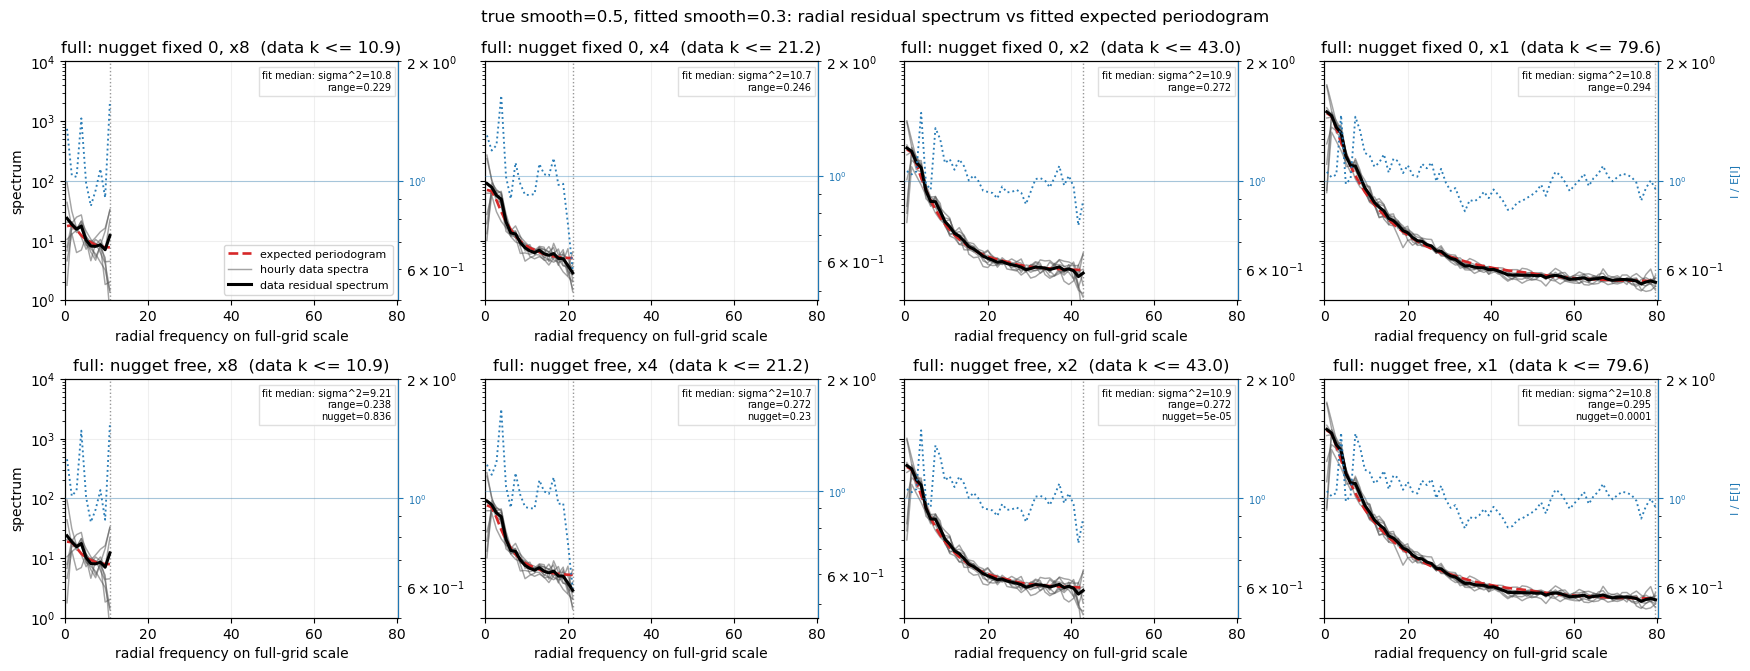

Saved shape diagnostic radial spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_shape_diagnostic_median_matched_theory_fit_s0p3.png


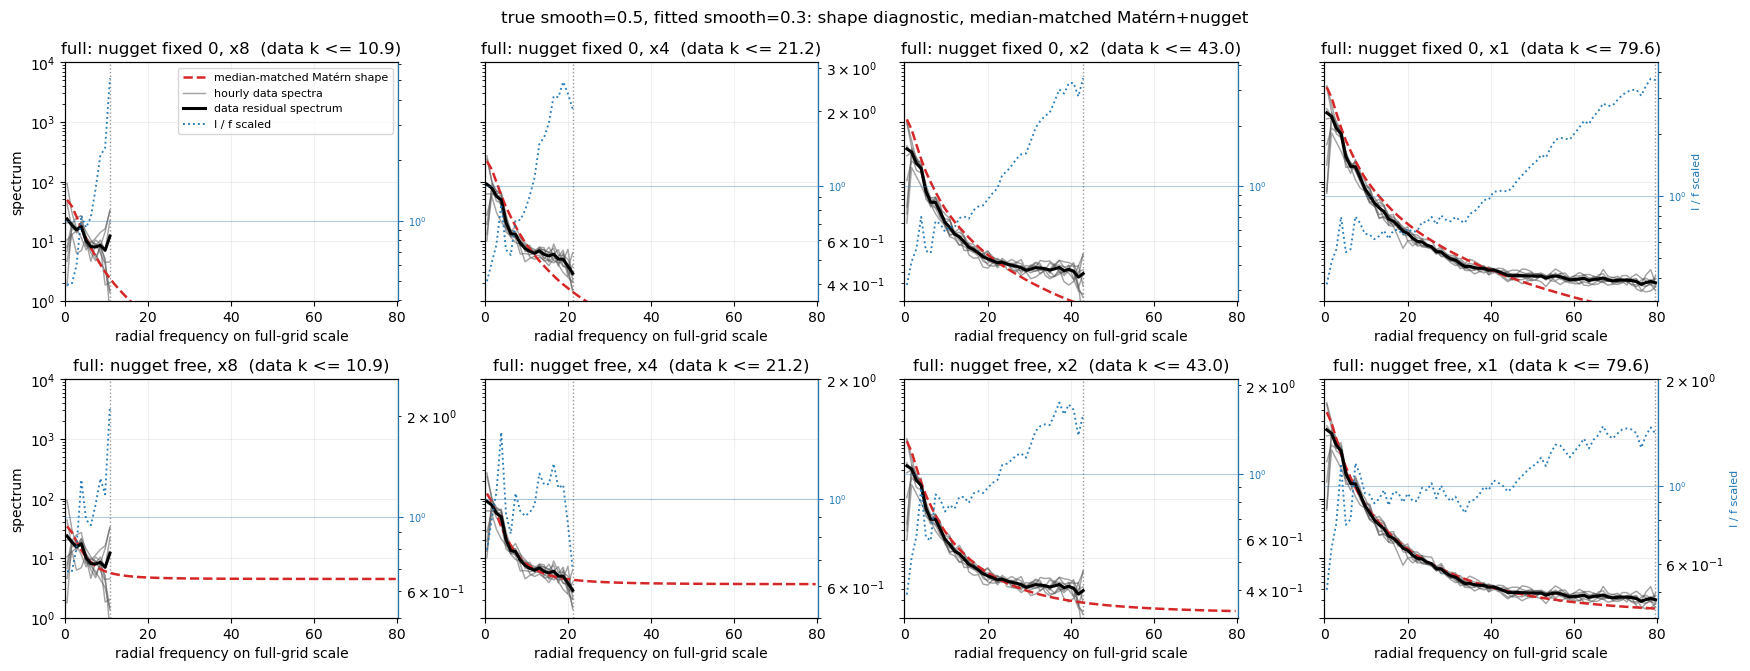

In [12]:
# %%
# Resolution-aware radial spectrum summaries.
# Data spectra are computed on the actual 2D thinned grid for each stride.
# Main theory curves use finite-sample E[I(W)], with no median rescaling.
spectral_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv'
spectral_df = pd.read_csv(spectral_path)
spectral_df['fit_smooth'] = pd.to_numeric(spectral_df['fit_smooth'], errors='coerce')
required_spectrum_cols = {'theory_spectrum_expected', 'theory_spectrum_scaled'}
missing_spectrum_cols = required_spectrum_cols.difference(spectral_df.columns)
if missing_spectrum_cols:
    raise ValueError(f'spectral_df lacks {sorted(missing_spectrum_cols)}; rerun the RUN_SPECTRUM cell after this update.')
print('Loaded spectral fit_smooth values:', sorted(spectral_df['fit_smooth'].dropna().unique()))

plot_spec = spectral_df.copy()
plot_spec['resolution_label'] = pd.Categorical(
    plot_spec['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

avg_low_data = (
    plot_spec.dropna(subset=['data_spectrum'])
    .groupby(['fit_smooth', 'variant', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        data_spectrum=('data_spectrum', 'mean'),
        n_hours=('hour_idx', 'nunique'),
        data_k_max=('data_k_max', 'mean'),
    )
    .reset_index()
)
low_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum_lowfreq_only_avg.csv'
avg_low_data.to_csv(low_path, index=False)
print('Saved low-frequency data spectrum:', low_path)

avg_theory_full = (
    plot_spec
    .groupby(['fit_smooth', 'variant', 'resolution_label', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
    )
    .reset_index()
)

positive_spectrum_vals = pd.concat(
    [
        pd.to_numeric(avg_low_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_theory_full['theory_spectrum_expected'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
positive_spectrum_vals = positive_spectrum_vals[positive_spectrum_vals > 0]
SPECTRUM_YLIM = (1e-1, 1e4) if positive_spectrum_vals.empty else (
    10 ** np.floor(np.log10(float(positive_spectrum_vals.min()))),
    10 ** np.ceil(np.log10(float(positive_spectrum_vals.max()))),
)
print('Radial spectrum y-limits:', SPECTRUM_YLIM)


def _ratio_from_arrays(x_vals, numerator_vals, denominator_vals):
    ratio_df = pd.DataFrame({
        'k_mid': pd.to_numeric(pd.Series(x_vals), errors='coerce'),
        'numerator': pd.to_numeric(pd.Series(numerator_vals), errors='coerce'),
        'denominator': pd.to_numeric(pd.Series(denominator_vals), errors='coerce'),
    }).replace([np.inf, -np.inf], np.nan)
    good = (
        ratio_df['k_mid'].notna()
        & ratio_df['numerator'].notna()
        & ratio_df['denominator'].notna()
        & (ratio_df['numerator'] > 0)
        & (ratio_df['denominator'] > 0)
    )
    ratio_df = ratio_df.loc[good, ['k_mid']].copy()
    if ratio_df.empty:
        ratio_df['ratio'] = []
        return ratio_df
    ratio_df['ratio'] = (
        pd.to_numeric(pd.Series(numerator_vals), errors='coerce').loc[good].to_numpy(dtype=float)
        / pd.to_numeric(pd.Series(denominator_vals), errors='coerce').loc[good].to_numpy(dtype=float)
    )
    return ratio_df.sort_values('k_mid')


def _ratio_frame(numerator_df, denominator_df, numerator_col, denominator_col, x_col='k_mid'):
    if numerator_df is None or denominator_df is None or numerator_df.empty or denominator_df.empty:
        return pd.DataFrame(columns=[x_col, 'ratio'])
    left = numerator_df[[x_col, numerator_col]].copy()
    right = denominator_df[[x_col, denominator_col]].copy()
    left[x_col] = pd.to_numeric(left[x_col], errors='coerce').round(10)
    right[x_col] = pd.to_numeric(right[x_col], errors='coerce').round(10)
    merged = left.merge(right, on=x_col, how='inner')
    if merged.empty:
        return pd.DataFrame(columns=[x_col, 'ratio'])
    return _ratio_from_arrays(merged[x_col], merged[numerator_col], merged[denominator_col])


def _add_ratio_axis(ax, ratio_df, ylabel=None, color='tab:blue'):
    if ratio_df is None or ratio_df.empty:
        return None
    ratio_df = ratio_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['k_mid', 'ratio'])
    ratio_df = ratio_df[ratio_df['ratio'] > 0].sort_values('k_mid')
    if ratio_df.empty:
        return None
    ratio_ax = ax.twinx()
    ratio_ax.plot(ratio_df['k_mid'], ratio_df['ratio'], color=color, linewidth=1.35, linestyle=':', alpha=0.95, zorder=8)
    ratio_ax.axhline(1.0, color=color, linewidth=0.8, linestyle='-', alpha=0.35, zorder=7)
    ratio_ax.set_yscale('log')
    vals = pd.to_numeric(ratio_df['ratio'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]
    if not vals.empty:
        lo_raw = float(vals.min())
        hi_raw = float(vals.max())
        lo = max(1e-3, min(0.5, lo_raw / 1.2))
        hi = min(1e3, max(2.0, hi_raw * 1.2))
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            ratio_ax.set_ylim(lo, hi)
    ratio_ax.tick_params(axis='y', colors=color, labelsize=7)
    ratio_ax.spines['right'].set_color(color)
    ratio_ax.grid(False)
    if ylabel:
        ratio_ax.set_ylabel(ylabel, color=color, fontsize=8)
    return ratio_ax


def _format_fit_param_label(source_df, fit_smooth, variant, resolution_label, prefix='fit median'):
    required = {'fit_smooth', 'variant', 'resolution_label', 'est_sigmasq', 'est_range', 'est_nugget'}
    if source_df is None or source_df.empty or not required.issubset(source_df.columns):
        return None
    df = source_df[
        np.isclose(pd.to_numeric(source_df['fit_smooth'], errors='coerce'), fit_smooth)
        & (source_df['variant'].astype(str) == str(variant))
        & (source_df['resolution_label'].astype(str) == str(resolution_label))
    ].copy()
    if df.empty:
        return None
    key_cols = [c for c in ['date_str', 'hour_idx', 'time_key', 'variant', 'resolution_label'] if c in df.columns]
    if key_cols:
        df = df.drop_duplicates(key_cols)
    sigmasq = float(pd.to_numeric(df['est_sigmasq'], errors='coerce').median())
    range_ = float(pd.to_numeric(df['est_range'], errors='coerce').median())
    nugget = float(pd.to_numeric(df['est_nugget'], errors='coerce').median())
    if not np.isfinite(sigmasq) or not np.isfinite(range_):
        return None
    label = f'{prefix}: sigma^2={sigmasq:.3g}\nrange={range_:.3g}'
    if str(variant) == 'nugget_free' or (np.isfinite(nugget) and abs(nugget) > EPS):
        label += f'\nnugget={nugget:.3g}'
    return label

labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
row_specs = [('nugget0', 'full: nugget fixed 0'), ('nugget_free', 'full: nugget free')]
fit_smooth_values = sorted(pd.to_numeric(plot_spec['fit_smooth'], errors='coerce').dropna().unique())

for fit_smooth in fit_smooth_values:
    fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
    if len(row_specs) == 1:
        axes = np.asarray([axes])
    for i, (variant, row_title) in enumerate(row_specs):
        for j, label in enumerate(labels_order):
            ax = axes[i, j]
            sub_data = avg_low_data[
                np.isclose(avg_low_data['fit_smooth'].astype(float), fit_smooth)
                & (avg_low_data['variant'] == variant)
                & (avg_low_data['resolution_label'].astype(str) == label)
                & (avg_low_data['k_mid'] > 0)
            ]
            sub_theory = avg_theory_full[
                np.isclose(avg_theory_full['fit_smooth'].astype(float), fit_smooth)
                & (avg_theory_full['variant'] == variant)
                & (avg_theory_full['resolution_label'].astype(str) == label)
                & (avg_theory_full['k_mid'] > 0)
            ]
            hour_sub = plot_spec[
                np.isclose(plot_spec['fit_smooth'].astype(float), fit_smooth)
                & (plot_spec['variant'] == variant)
                & (plot_spec['resolution_label'].astype(str) == label)
                & (plot_spec['k_mid'] > 0)
                & plot_spec['data_spectrum'].notna()
            ]
            if sub_data.empty or sub_theory.empty:
                ax.set_visible(False)
                continue
            k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
            param_label = _format_fit_param_label(plot_spec, fit_smooth, variant, label)
            if param_label:
                ax.text(0.98, 0.96, param_label, transform=ax.transAxes, ha='right', va='top', fontsize=7,
                        bbox=dict(facecolor='white', edgecolor='0.85', alpha=0.82, pad=2.5))
            ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_expected'], color='tab:red', linewidth=1.9, linestyle='--', label='expected periodogram', zorder=3)
            for hour_idx, hs in hour_sub.groupby('hour_idx'):
                hour_label = 'hourly data spectra' if (i == 0 and j == 0 and int(hour_idx) == int(hour_sub['hour_idx'].min())) else None
                ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
            ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
            ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_expected')
            _add_ratio_axis(ax, ratio_df, ylabel='I / E[I]' if j == len(labels_order) - 1 else None)
            ax.axvline(k_cut, color='0.55', linewidth=1.0, linestyle=':', alpha=0.9)
            ax.set_xlim(0, FULL_K_PLOT_MAX)
            ax.set_ylim(*SPECTRUM_YLIM)
            ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
            ax.set_xlabel('radial frequency on full-grid scale')
            if j == 0:
                ax.set_ylabel('spectrum')
            ax.set_yscale('log')
            ax.grid(alpha=0.2)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    fig.suptitle(f'true smooth={TRUE_SMOOTH}, fitted smooth={fit_smooth}: radial residual spectrum vs fitted expected periodogram')
    fig.tight_layout()
    combined_spectrum_plot_path = OUT_DIR / f'{OUT_PREFIX}_data_vs_expected_periodogram_fit_s{smooth_tag(fit_smooth)}.png'
    fig.savefig(combined_spectrum_plot_path, dpi=180, bbox_inches='tight')
    print('Saved radial expected-periodogram plot:', combined_spectrum_plot_path)
    plt.show()

    fig_shape, axes_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
    if len(row_specs) == 1:
        axes_shape = np.asarray([axes_shape])
    for i, (variant, row_title) in enumerate(row_specs):
        for j, label in enumerate(labels_order):
            ax = axes_shape[i, j]
            sub_data = avg_low_data[
                np.isclose(avg_low_data['fit_smooth'].astype(float), fit_smooth)
                & (avg_low_data['variant'] == variant)
                & (avg_low_data['resolution_label'].astype(str) == label)
                & (avg_low_data['k_mid'] > 0)
            ]
            sub_theory = avg_theory_full[
                np.isclose(avg_theory_full['fit_smooth'].astype(float), fit_smooth)
                & (avg_theory_full['variant'] == variant)
                & (avg_theory_full['resolution_label'].astype(str) == label)
                & (avg_theory_full['k_mid'] > 0)
            ]
            hour_sub = plot_spec[
                np.isclose(plot_spec['fit_smooth'].astype(float), fit_smooth)
                & (plot_spec['variant'] == variant)
                & (plot_spec['resolution_label'].astype(str) == label)
                & (plot_spec['k_mid'] > 0)
                & plot_spec['data_spectrum'].notna()
            ]
            if sub_data.empty or sub_theory.empty:
                ax.set_visible(False)
                continue
            k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
            ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_scaled'], color='tab:red', linewidth=1.8, linestyle='--', label='median-matched Matérn shape', zorder=3)
            for hour_idx, hs in hour_sub.groupby('hour_idx'):
                hour_label = 'hourly data spectra' if (i == 0 and j == 0 and int(hour_idx) == int(hour_sub['hour_idx'].min())) else None
                ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
            ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
            ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_scaled')
            _add_ratio_axis(ax, ratio_df, ylabel='I / f scaled' if j == len(labels_order) - 1 else None)
            ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / f scaled')
            ax.axvline(k_cut, color='0.55', linewidth=1.0, linestyle=':', alpha=0.9)
            ax.set_xlim(0, FULL_K_PLOT_MAX)
            ax.set_ylim(*SPECTRUM_YLIM)
            ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
            ax.set_xlabel('radial frequency on full-grid scale')
            if j == 0:
                ax.set_ylabel('spectrum')
            ax.set_yscale('log')
            ax.grid(alpha=0.2)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    fig_shape.suptitle(f'true smooth={TRUE_SMOOTH}, fitted smooth={fit_smooth}: shape diagnostic, median-matched Matérn+nugget')
    fig_shape.tight_layout()
    shape_diagnostic_plot_path = OUT_DIR / f'{OUT_PREFIX}_shape_diagnostic_median_matched_theory_fit_s{smooth_tag(fit_smooth)}.png'
    fig_shape.savefig(shape_diagnostic_plot_path, dpi=180, bbox_inches='tight')
    print('Saved shape diagnostic radial spectrum plot:', shape_diagnostic_plot_path)
    plt.show()

Partial-profile rows by fitted smooth:


,fit_smooth,variant,profile_type,n
0,0.3,nugget0,range_only,32
1,0.3,nugget0,sigma_only,32
2,0.3,nugget_free,range_only,32
3,0.3,nugget_free,sigma_only,32


Saved partial-profile radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_partial_profile_radial_spectrum.csv
Saved partial-profile low-frequency data spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_partial_profile_radial_spectrum_lowfreq_only_avg.csv
Combined expected-periodogram y-limits: (1.0, 10000.0)
Plotting expected-periodogram spectrum matrices for fitted smooths: [0.3]
Saved combined expected-periodogram spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_pure_space_true_s05_fit_s03_clusterb2_052426_combined_full_profile_expected_periodogram_fit_s0p3.png


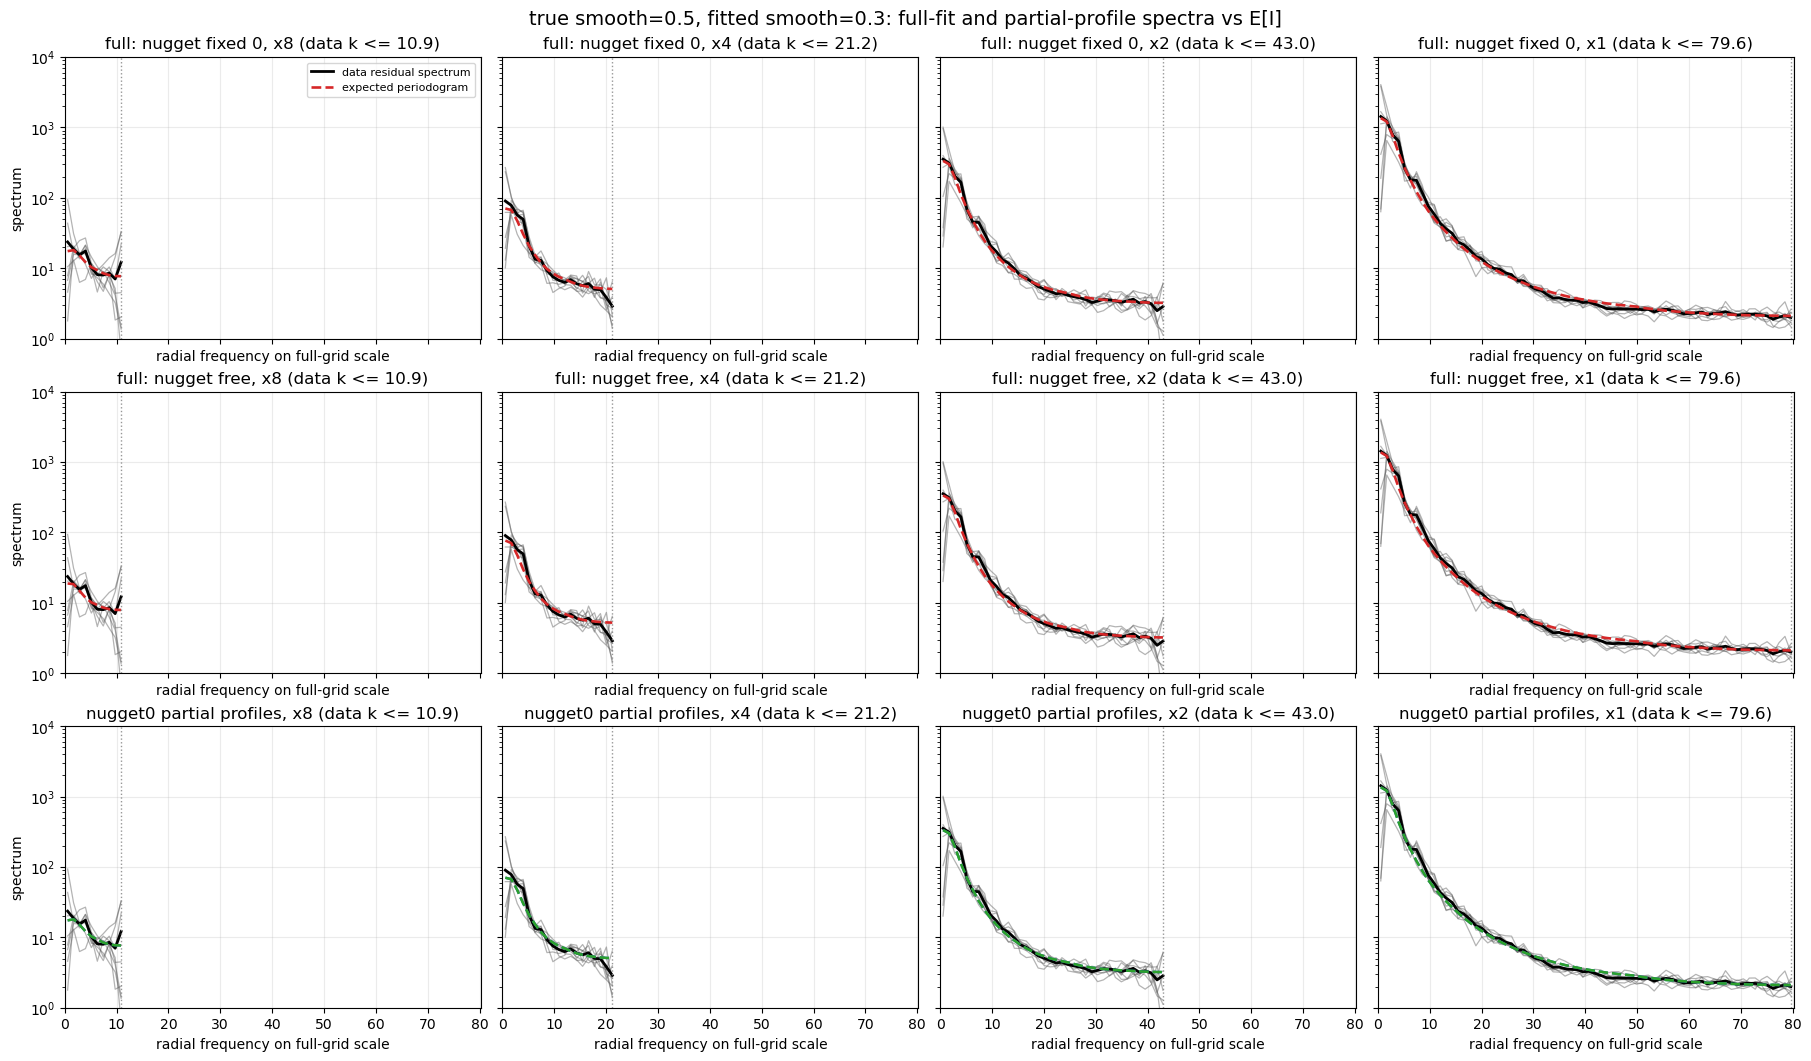

In [13]:
# %%
# Spectral diagnostics for partial-profile fits, one 3x4 matrix per fitted smooth.
# Partial-profile curves now use finite-sample E[I(W)] as the main red/blue/green comparison.
profile_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv')
profile_df['fit_smooth'] = pd.to_numeric(profile_df['fit_smooth'], errors='coerce')
print('Partial-profile rows by fitted smooth:')
display(profile_df.groupby(['fit_smooth', 'variant', 'profile_type'], dropna=False).size().rename('n').reset_index())

if RUN_SPECTRUM and not profile_df.empty:
    profile_spectral_rows = []
    for r in profile_df.itertuples(index=False):
        fit_smooth = float(getattr(r, 'fit_smooth', getattr(r, 'smooth')))
        grid, mask, time_key, n_valid_spectrum, lat_axis, lon_axis = detrended_residual_grid(
            int(r.hour_idx), int(r.resolution_stride)
        )
        data_p = masked_periodogram(grid, mask)
        k_data, _, _, _ = frequency_grid_for_axes(lat_axis, lon_axis)
        data_rad = radial_average(data_p, k_data).rename(columns={'spectrum': 'data_spectrum'})

        theory_shape_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.est_nugget, fit_smooth, OMEGA2_FULL)
        theory_shape_rad = radial_average(theory_shape_p, K_FULL_RADIAL).rename(columns={'spectrum': 'theory_spectrum_shape'})
        theory_expected_p = expected_periodogram_dw_style(
            r.est_sigmasq, r.est_range, r.est_nugget, fit_smooth, mask, lat_axis, lon_axis
        )
        theory_expected_rad = radial_average(theory_expected_p, k_data).rename(columns={'spectrum': 'theory_spectrum_expected'})

        merged = theory_shape_rad.merge(theory_expected_rad[['k_bin', 'theory_spectrum_expected']], on='k_bin', how='left')
        merged = merged.merge(data_rad[['k_bin', 'data_spectrum', 'n_freq']], on='k_bin', how='left', suffixes=('', '_data'))
        scale = scale_theory_to_data(merged['data_spectrum'], merged['theory_spectrum_shape'], method='geomean')
        merged['theory_spectrum_scaled'] = merged['theory_spectrum_shape'] * scale
        data_k_max = float(data_rad['k_mid'].max()) if not data_rad.empty else np.nan

        for m in merged.itertuples(index=False):
            profile_spectral_rows.append({
                'date_str': str(r.date_str),
                'true_smooth': float(getattr(r, 'true_smooth', TRUE_SMOOTH)),
                'fit_smooth': float(fit_smooth),
                'hour_idx': int(r.hour_idx),
                'time_key': str(r.time_key),
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': str(r.resolution_label),
                'variant': str(r.variant),
                'profile_type': str(r.profile_type),
                'fit_type': str(r.profile_type),
                'smooth': float(fit_smooth),
                'n_valid_spectrum': int(n_valid_spectrum),
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range),
                'est_nugget': float(r.est_nugget),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'k_mean': float(m.k_mean),
                'n_freq': int(getattr(m, 'n_freq_data')) if pd.notna(getattr(m, 'n_freq_data', np.nan)) else 0,
                'data_k_max': data_k_max,
                'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

    profile_spectral_df = pd.DataFrame(profile_spectral_rows)
    profile_spectral_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile_radial_spectrum.csv'
    profile_spectral_df.to_csv(profile_spectral_path, index=False)
    print('Saved partial-profile radial spectrum:', profile_spectral_path)

    plot_prof = profile_spectral_df.copy()
    plot_prof['resolution_label'] = pd.Categorical(
        plot_prof['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
    )

    avg_prof_low = (
        plot_prof.dropna(subset=['data_spectrum'])
        .groupby(['fit_smooth', 'variant', 'profile_type', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
        .agg(
            k_mid=('k_mid', 'mean'),
            data_spectrum=('data_spectrum', 'mean'),
            n_hours=('hour_idx', 'nunique'),
            data_k_max=('data_k_max', 'mean'),
        )
        .reset_index()
    )
    avg_prof_theory = (
        plot_prof
        .groupby(['fit_smooth', 'variant', 'profile_type', 'resolution_label', 'k_bin'], observed=False)
        .agg(
            k_mid=('k_mid', 'mean'),
            theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
            theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
        )
        .reset_index()
    )
    avg_prof_low_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile_radial_spectrum_lowfreq_only_avg.csv'
    avg_prof_low.to_csv(avg_prof_low_path, index=False)
    print('Saved partial-profile low-frequency data spectrum:', avg_prof_low_path)

    positive_spectrum_vals = pd.concat(
        [
            pd.to_numeric(avg_low_data['data_spectrum'], errors='coerce'),
            pd.to_numeric(avg_theory_full['theory_spectrum_expected'], errors='coerce'),
            pd.to_numeric(avg_prof_low['data_spectrum'], errors='coerce'),
            pd.to_numeric(avg_prof_theory['theory_spectrum_expected'], errors='coerce'),
        ],
        ignore_index=True,
    ).replace([np.inf, -np.inf], np.nan).dropna()
    positive_spectrum_vals = positive_spectrum_vals[positive_spectrum_vals > 0]
    SPECTRUM_YLIM = (1e-1, 1e4) if positive_spectrum_vals.empty else (
        10 ** np.floor(np.log10(float(positive_spectrum_vals.min()))),
        10 ** np.ceil(np.log10(float(positive_spectrum_vals.max()))),
    )
    print('Combined expected-periodogram y-limits:', SPECTRUM_YLIM)

    labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
    row_specs = [
        ('nugget0', 'full: nugget fixed 0'),
        ('nugget_free', 'full: nugget free'),
        ('profiles', 'nugget0 partial profiles'),
    ]

    fit_smooth_values = sorted(set(pd.to_numeric(plot_spec['fit_smooth'], errors='coerce').dropna().unique()).union(set(pd.to_numeric(plot_prof['fit_smooth'], errors='coerce').dropna().unique())))
    print('Plotting expected-periodogram spectrum matrices for fitted smooths:', fit_smooth_values)
    for fit_smooth in fit_smooth_values:
        fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(18, 10.5), constrained_layout=True, sharex=True, sharey=True)
        for i, (row_key, row_title) in enumerate(row_specs):
            for j, label in enumerate(labels_order):
                ax = axes[i, j]
                if row_key == 'profiles':
                    sub_data = avg_prof_low[
                        np.isclose(avg_prof_low['fit_smooth'].astype(float), fit_smooth)
                        & (avg_prof_low['variant'] == 'nugget0')
                        & (avg_prof_low['profile_type'] == 'sigma_only')
                        & (avg_prof_low['resolution_label'].astype(str) == label)
                        & (avg_prof_low['k_mid'] > 0)
                    ].copy()
                    sub_sigma = avg_prof_theory[
                        np.isclose(avg_prof_theory['fit_smooth'].astype(float), fit_smooth)
                        & (avg_prof_theory['variant'] == 'nugget0')
                        & (avg_prof_theory['profile_type'] == 'sigma_only')
                        & (avg_prof_theory['resolution_label'].astype(str) == label)
                        & (avg_prof_theory['k_mid'] > 0)
                    ].copy()
                    sub_range = avg_prof_theory[
                        np.isclose(avg_prof_theory['fit_smooth'].astype(float), fit_smooth)
                        & (avg_prof_theory['variant'] == 'nugget0')
                        & (avg_prof_theory['profile_type'] == 'range_only')
                        & (avg_prof_theory['resolution_label'].astype(str) == label)
                        & (avg_prof_theory['k_mid'] > 0)
                    ].copy()
                    hour_sub = plot_prof[
                        np.isclose(plot_prof['fit_smooth'].astype(float), fit_smooth)
                        & (plot_prof['variant'] == 'nugget0')
                        & (plot_prof['profile_type'] == 'sigma_only')
                        & (plot_prof['resolution_label'].astype(str) == label)
                        & (plot_prof['k_mid'] > 0)
                        & plot_prof['data_spectrum'].notna()
                    ]
                    if sub_data.empty or sub_sigma.empty or sub_range.empty:
                        ax.set_visible(False)
                        continue
                    k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
                    for _, hs in hour_sub.groupby('hour_idx'):
                        ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.45, linewidth=0.9)
                    ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.0, label='data residual spectrum')
                    ax.plot(sub_sigma['k_mid'], sub_sigma['theory_spectrum_expected'], color='tab:blue', linewidth=1.8, linestyle='--', label='sigma-only E[I]')
                    ax.plot(sub_range['k_mid'], sub_range['theory_spectrum_expected'], color='tab:green', linewidth=1.8, linestyle='--', label='range-only E[I]')
                else:
                    sub_data = avg_low_data[
                        np.isclose(avg_low_data['fit_smooth'].astype(float), fit_smooth)
                        & (avg_low_data['variant'] == row_key)
                        & (avg_low_data['resolution_label'].astype(str) == label)
                        & (avg_low_data['k_mid'] > 0)
                    ].copy()
                    sub_theory = avg_theory_full[
                        np.isclose(avg_theory_full['fit_smooth'].astype(float), fit_smooth)
                        & (avg_theory_full['variant'] == row_key)
                        & (avg_theory_full['resolution_label'].astype(str) == label)
                        & (avg_theory_full['k_mid'] > 0)
                    ].copy()
                    hour_sub = plot_spec[
                        np.isclose(plot_spec['fit_smooth'].astype(float), fit_smooth)
                        & (plot_spec['variant'] == row_key)
                        & (plot_spec['resolution_label'].astype(str) == label)
                        & (plot_spec['k_mid'] > 0)
                        & plot_spec['data_spectrum'].notna()
                    ]
                    if sub_data.empty or sub_theory.empty:
                        ax.set_visible(False)
                        continue
                    k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
                    for _, hs in hour_sub.groupby('hour_idx'):
                        ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.45, linewidth=0.9)
                    ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.0, label='data residual spectrum')
                    ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_expected'], color='tab:red', linewidth=1.9, linestyle='--', label='expected periodogram')
                ax.axvline(k_cut, color='0.55', linestyle=':', linewidth=1.0, alpha=0.9)
                ax.set_xlim(0, FULL_K_PLOT_MAX)
                ax.set_ylim(*SPECTRUM_YLIM)
                ax.set_yscale('log')
                ax.set_title(f'{row_title}, {label} (data k <= {k_cut:.1f})')
                ax.set_xlabel('radial frequency on full-grid scale')
                if j == 0:
                    ax.set_ylabel('spectrum')
                ax.grid(True, alpha=0.25)
        axes[0, 0].legend(fontsize=8)
        fig.suptitle(f'true smooth={TRUE_SMOOTH}, fitted smooth={fit_smooth}: full-fit and partial-profile spectra vs E[I]', fontsize=14)
        spectrum_plot_path = OUT_DIR / f'{OUT_PREFIX}_combined_full_profile_expected_periodogram_fit_s{smooth_tag(fit_smooth)}.png'
        fig.savefig(spectrum_plot_path, dpi=180, bbox_inches='tight')
        print('Saved combined expected-periodogram spectrum plot:', spectrum_plot_path)
        plt.show()